In [ ]:
import os, sys
from pathlib import Path

# Navigate to project root (parent of notebooks/)
_cwd = Path().resolve()
PROJECT_ROOT = _cwd.parent if _cwd.name == 'notebooks' else _cwd
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import config

Path('outputs/models').mkdir(parents=True, exist_ok=True)
Path('outputs/figures').mkdir(parents=True, exist_ok=True)

print("✅ Ready.")

In [ ]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.metrics import confusion_matrix, roc_auc_score
from tensorflow import keras

from src.config import SENSORS, WINDOW_SIZE, WINDOW_STEP, EVENTS

# 04 — Inference & Recommendation System

Demonstration of the anomaly detection system on real-world test data.

**Three Alert Levels:**
- 🟢 NORMAL  — Anomaly probability < 30%
- 🟡 WATCH   — Probability 30–50%, requires observation  
- 🔴 ANOMALY — Probability > 50%, requires immediate intervention

**Models:** All trained models are loaded and compared against the same test window examples.

In [ ]:
import pickle
import pandas as pd
import numpy as np
from tensorflow import keras
from pathlib import Path

# Load all trained model artifacts
with open("outputs/models/random_forest_baseline.pkl",  "rb") as f:
    rf_base = pickle.load(f)
with open("outputs/models/random_forest_tuned.pkl",     "rb") as f:
    rf_tuned = pickle.load(f)
with open("outputs/models/xgboost_baseline.pkl",        "rb") as f:
    xgb_base = pickle.load(f)
with open("outputs/models/xgboost_tuned.pkl",           "rb") as f:
    xgb_tuned = pickle.load(f)

lstm_model = keras.models.load_model("outputs/models/lstm_baseline.keras")

# Load test features for Classical ML models (RF/XGBoost)
df_feat_test = pd.read_parquet("outputs/features_test.parquet")

# Filter out target columns and dead sensors
DEAD_FEATURES = ["P-PDG_mean", "P-PDG_std", "P-PDG_min",
                 "P-PDG_max", "P-PDG_range", "P-PDG_trend"]
feature_cols = [c for c in df_feat_test.columns
                if c not in ("label", "event_type", "source")
                and c not in DEAD_FEATURES]

X_test = df_feat_test[feature_cols].values
y_test = df_feat_test["label"].values

# Load raw time-series data for the LSTM model
df_raw_test = pd.read_parquet("outputs/raw_test.parquet")
LSTM_SENSORS = [s for s in SENSORS if s != "P-PDG"]

print(f"Models loaded: RF baseline, RF tuned, XGBoost baseline, XGBoost tuned, LSTM")
print(f"Test windows:  {len(X_test):,}")

Models loaded: RF baseline, RF tuned, XGBoost baseline, XGBoost tuned, LSTM
Test windows:  172,016


In [ ]:
def get_recommendation(proba: float) -> dict:
    """Assigns a status and recommended action based on anomaly probability."""
    if proba < 0.30:
        return {
            "status":  "🟢 NORMAL",
            "level":   0,
            "action":  "No action required. System operating normally.",
            "color":   "green",
        }
    elif proba < 0.50:
        return {
            "status":  "🟡 WATCH",
            "level":   1,
            "action":  "Monitor closely. Early warning signs detected.",
            "color":   "orange",
        }
    else:
        return {
            "status":  "🔴 ANOMALY",
            "level":   2,
            "action":  "Immediate inspection recommended. High anomaly probability.",
            "color":   "red",
        }


def predict_all_models(x_feat: np.ndarray, x_seq: np.ndarray) -> dict:
    """
    Runs inference across all models for comparison.
    x_feat: 1D feature vector for RF/XGBoost | shape (n_features,)
    x_seq:  3D sequence tensor for LSTM      | shape (1, window_size, n_sensors)
    """
    results = {}

    # Iterate through classical models
    for name, model in [
        ("RF Baseline",      rf_base),
        ("RF Tuned",         rf_tuned),
        ("XGBoost Baseline", xgb_base),
        ("XGBoost Tuned",    xgb_tuned),
    ]:
        proba = model.predict_proba(x_feat.reshape(1, -1))[0, 1]
        rec   = get_recommendation(proba)
        results[name] = {"proba": round(float(proba), 3), **rec}

    # Inference for Deep Learning model
    proba_lstm = float(lstm_model.predict(x_seq, verbose=0)[0, 0])
    rec = get_recommendation(proba_lstm)
    results["LSTM"] = {"proba": round(proba_lstm, 3), **rec}

    return results

## 1. Single Window Inference

We select three specific cases from the test set for qualitative analysis:
- A known **Normal** window
- A known **Anomaly** window
- A **Borderline** case (where the model shows lower confidence)

In [ ]:
# Select representative examples
normal_idx   = np.where(y_test == 0)[0][42]   # Arbitrary normal window
anomaly_idx  = np.where(y_test == 1)[0][42]   # Arbitrary anomaly window

# Find a borderline case where RF Tuned is uncertain (probability near 0.45)
all_probas = rf_tuned.predict_proba(X_test)[:, 1]
border_idx = np.argmin(np.abs(all_probas - 0.45))

examples = {
    "Normal window":   normal_idx,
    "Anomaly window":  anomaly_idx,
    "Borderline":      border_idx,
}

print("Selected windows for inference demo:")
for name, idx in examples.items():
    true_label = "Anomaly" if y_test[idx] == 1 else "Normal"
    source = df_feat_test.iloc[idx]["source"]
    print(f"  {name:<18}: idx={idx}, true={true_label}, source={source}")

Selected windows:
  Normal window     : idx=42, true=Normal, source=WELL-00001_20170218150135.parquet
  Anomaly window    : idx=757, true=Anomaly, source=WELL-00001_20170316230000.parquet
  Borderline        : idx=168921, true=Normal, source=WELL-00037_20181011071238.parquet


In [ ]:
def get_lstm_window(df_raw: pd.DataFrame, source: str,
                    window_idx: int) -> np.ndarray:
    """Extracts a specific raw window for the LSTM model based on source file and index."""
    group = df_raw[df_raw["source"] == source].reset_index(drop=True)
    start = window_idx * WINDOW_STEP
    window = group.iloc[start: start + WINDOW_SIZE][LSTM_SENSORS].values
    return window.astype(np.float32).reshape(1, WINDOW_SIZE, len(LSTM_SENSORS))


# Map indices in df_feat_test to (source file, local window sequence number)
window_meta = df_feat_test[["source"]].copy().reset_index(drop=True)
window_meta["local_idx"] = window_meta.groupby("source").cumcount()

In [ ]:
print("=" * 60)
for example_name, idx in examples.items():
    x_feat   = X_test[idx]
    source   = window_meta.loc[idx, "source"]
    local_i  = window_meta.loc[idx, "local_idx"]
    x_seq    = get_lstm_window(df_raw_test, source, local_i)

    true_label = "🔴 ANOMALY" if y_test[idx] == 1 else "🟢 NORMAL"
    print(f"\n{'─'*60}")
    print(f"Window: {example_name}  |  True label: {true_label}")
    print(f"Source: {source}")
    print(f"{'─'*60}")

    predictions = predict_all_models(x_feat, x_seq)
    for model_name, res in predictions.items():
        print(f"  {model_name:<20} p={res['proba']:.3f}  {res['status']}")
        print(f"  {'':20} → {res['action']}")

print(f"\n{'='*60}")


────────────────────────────────────────────────────────────
Window: Normal window  |  True label: 🟢 NORMAL
Source: WELL-00001_20170218150135.parquet
────────────────────────────────────────────────────────────
  RF Baseline          p=0.000  🟢 NORMAL
                       → No action required. System operating normally.
  RF Tuned             p=0.002  🟢 NORMAL
                       → No action required. System operating normally.
  XGBoost Baseline     p=0.006  🟢 NORMAL
                       → No action required. System operating normally.
  XGBoost Tuned        p=0.028  🟢 NORMAL
                       → No action required. System operating normally.
  LSTM                 p=0.327  🟡 WATCH
                       → Monitor closely. Early warning signs detected.

────────────────────────────────────────────────────────────
Window: Anomaly window  |  True label: 🔴 ANOMALY
Source: WELL-00001_20170316230000.parquet
────────────────────────────────────────────────────────────
  RF Basel

## 2. Threshold Analysis

Analysis of how the classification threshold affects the balance between False Negatives (FN) and False Positives (FP).

While 0.5 is the default threshold, safety-critical systems often require tuning this value.

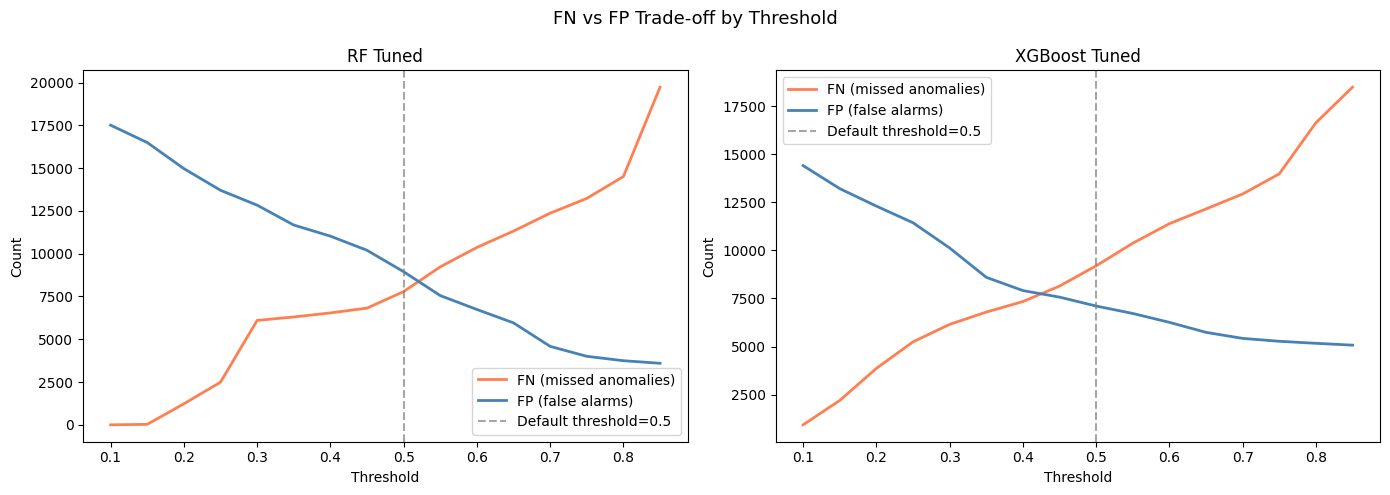

Interpretation: lower threshold → fewer FN (safer) but more FP (more alerts)
For safety-critical systems, threshold ~0.3-0.4 may be more appropriate.


In [ ]:
thresholds = np.arange(0.1, 0.9, 0.05)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model) in zip(axes, [
    ("RF Tuned",      rf_tuned),
    ("XGBoost Tuned", xgb_tuned),
]):
    probas = model.predict_proba(X_test)[:, 1]
    fns, fps = [], []

    for t in thresholds:
        preds = (probas >= t).astype(int)
        cm    = confusion_matrix(y_test, preds)
        fns.append(cm[1, 0])
        fps.append(cm[0, 1])

    ax.plot(thresholds, fns, "coral",    linewidth=2, label="FN (missed anomalies)")
    ax.plot(thresholds, fps, "steelblue", linewidth=2, label="FP (false alarms)")
    ax.axvline(x=0.5, color="gray", linestyle="--", alpha=0.7, label="Default threshold=0.5")
    ax.set_title(name)
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Count")
    ax.legend()

plt.suptitle("FN vs FP Trade-off by Threshold", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/figures/threshold_analysis.png", dpi=150)
plt.show()

print("Interpretation: lower threshold → fewer FN (safer) but more FP (more alerts)")
print("For safety-critical systems, threshold ~0.3-0.4 may be more appropriate.")

## 3. Anomaly Timeline Visualization

Visualizing the model predictions across a time-series for a single well. This helps identify where the model is correct and how stable its predictions are over time.

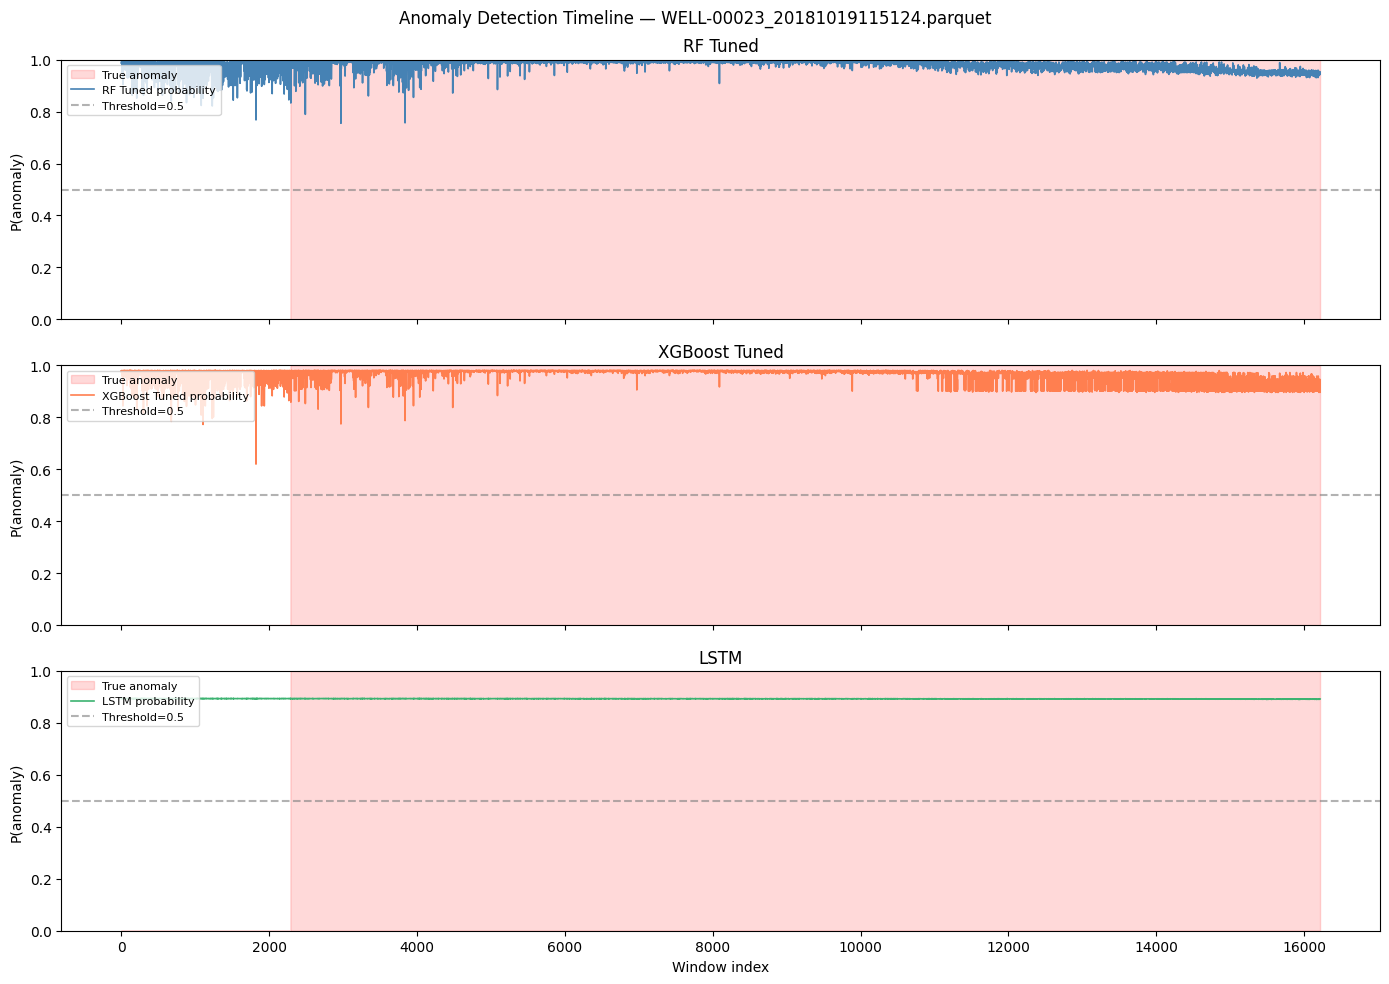

In [ ]:
# Select a test well that contains anomalies for visualization
sources_with_anomaly = (df_feat_test[df_feat_test["label" ] == 1]
                        ["source"].value_counts().index[:5].tolist())

chosen_source = sources_with_anomaly[0]
mask = df_feat_test["source"] == chosen_source
df_source = df_feat_test[mask].reset_index(drop=True)
X_source  = df_source[feature_cols].values
y_source  = df_source["label"].values

# Generate predictions for Classical ML
probas_rf   = rf_tuned.predict_proba(X_source)[:, 1]
probas_xgb  = xgb_tuned.predict_proba(X_source)[:, 1]

# Prepare and generate predictions for LSTM
raw_source = df_raw_test[df_raw_test["source"] == chosen_source].reset_index(drop=True)
n = len(raw_source)
lstm_windows = []
for start in range(0, n - WINDOW_SIZE, WINDOW_STEP):
    w = raw_source.iloc[start:start+WINDOW_SIZE][LSTM_SENSORS].values
    lstm_windows.append(w.astype(np.float32))
X_lstm_source = np.array(lstm_windows)
probas_lstm = lstm_model.predict(X_lstm_source, verbose=0).flatten()

# Align lengths for plotting
min_len = min(len(probas_rf), len(probas_xgb), len(probas_lstm))
t = np.arange(min_len)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, (name, probas, color) in zip(axes, [
    ("RF Tuned",      probas_rf[:min_len],   "steelblue"),
    ("XGBoost Tuned", probas_xgb[:min_len],  "coral"),
    ("LSTM",          probas_lstm[:min_len],  "mediumseagreen"),
]):
    ax.fill_between(t, 0, y_source[:min_len],
                    alpha=0.15, color="red", label="True anomaly")
    ax.plot(t, probas, color=color, linewidth=1.2, label=f"{name} probability")
    ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.6, label="Threshold=0.5")
    ax.set_ylim(0, 1)
    ax.set_ylabel("P(anomaly)")
    ax.set_title(name)
    ax.legend(fontsize=8, loc="upper left")

axes[-1].set_xlabel("Window index")
plt.suptitle(f"Anomaly Detection Timeline — {chosen_source}", fontsize=12)
plt.tight_layout()
plt.savefig("outputs/figures/inference_timeline.png", dpi=150)
plt.show()

## 4. Explainability — SHAP Analysis

SHAP (SHapley Additive exPlanations) is used to interpret the decisions made by the black-box models.

- **Summary plot** — Global feature importance across a sample of data.
- **Bar plot / Waterfall** — Local explanation for a specific anomalous window.

In [ ]:
import shap

Computing SHAP values for XGBoost Tuned...


/tmp/ipykernel_1558/3496499369.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


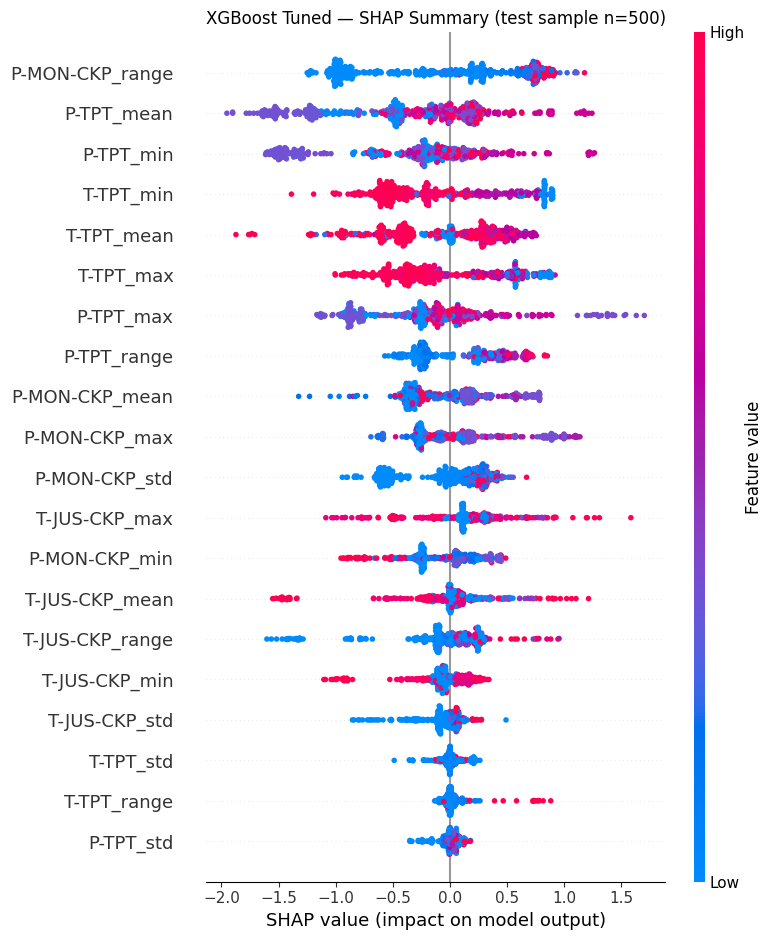

In [ ]:
print("Computing SHAP values for XGBoost Tuned...")
explainer_xgb = shap.TreeExplainer(xgb_tuned)

np.random.seed(42)
sample_idx  = np.random.choice(len(X_test), 500, replace=False)
X_sample    = X_test[sample_idx]
shap_values = explainer_xgb.shap_values(X_sample)

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_sample,
    feature_names=feature_cols,
    show=False,
)
plt.title("XGBoost Tuned — SHAP Summary (test sample n=500)", fontsize=12)
plt.tight_layout()
plt.savefig("outputs/figures/shap_xgb_summary.png", dpi=150, bbox_inches="tight")
plt.show()

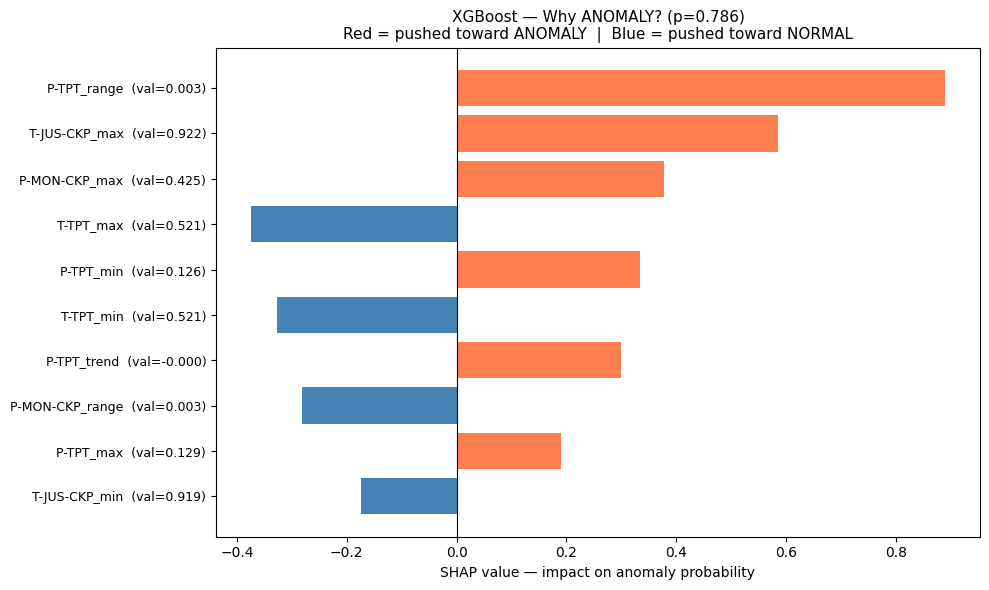

In [ ]:
x_explain     = X_test[anomaly_idx]
proba_explain = xgb_tuned.predict_proba(x_explain.reshape(1, -1))[0, 1]
shap_single   = explainer_xgb.shap_values(x_explain.reshape(1, -1))[0]

top10_idx   = np.argsort(np.abs(shap_single))[-10:][::-1]
top10_names = [feature_cols[i] for i in top10_idx]
top10_shap  = shap_single[top10_idx]
top10_vals  = x_explain[top10_idx]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["coral" if v > 0 else "steelblue" for v in top10_shap]
ax.barh(range(10), top10_shap[::-1], color=colors[::-1])
ax.set_yticks(range(10))
ax.set_yticklabels(
    [f"{n}  (val={v:.3f})" for n, v in
     zip(top10_names[::-1], top10_vals[::-1])],
    fontsize=9
)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_xlabel("SHAP value — impact on anomaly probability")
ax.set_title(
    f"XGBoost — Why ANOMALY? (p={proba_explain:.3f})\n"
    f"Red = pushed toward ANOMALY  |  Blue = pushed toward NORMAL",
    fontsize=11
)
plt.tight_layout()
plt.savefig("outputs/figures/shap_xgb_waterfall.png", dpi=150)
plt.show()

Computing SHAP values for RF Tuned...
Raw shape: (500, 24, 2)
Plot shape: (500, 24)


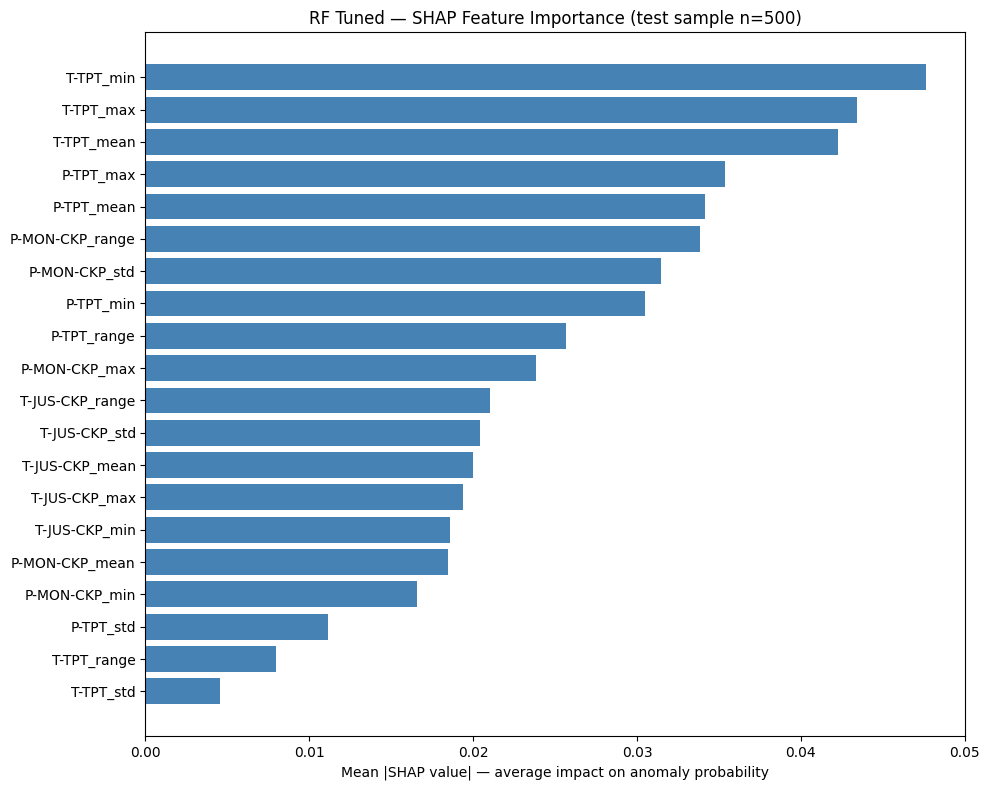

In [ ]:
print("Computing SHAP values for RF Tuned...")
explainer_rf = shap.TreeExplainer(rf_tuned)
shap_rf_raw  = explainer_rf.shap_values(X_sample)

print(f"Raw shape: {np.array(shap_rf_raw).shape}")

if isinstance(shap_rf_raw, np.ndarray) and shap_rf_raw.ndim == 3:
    shap_rf_plot = shap_rf_raw[:, :, 1]
elif isinstance(shap_rf_raw, list):
    shap_rf_plot = np.array(shap_rf_raw[1])
else:
    shap_rf_plot = shap_rf_raw

print(f"Plot shape: {shap_rf_plot.shape}")

mean_abs_shap = np.abs(shap_rf_plot).mean(axis=0)
importance_df = pd.DataFrame({
    "feature":          feature_cols,
    "shap_importance":  mean_abs_shap
}).sort_values("shap_importance", ascending=True).tail(20)

plt.figure(figsize=(10, 8))
plt.barh(importance_df["feature"], importance_df["shap_importance"],
         color="steelblue")
plt.xlabel("Mean |SHAP value| — average impact on anomaly probability")
plt.title("RF Tuned — SHAP Feature Importance (test sample n=500)", fontsize=12)
plt.tight_layout()
plt.savefig("outputs/figures/shap_rf_summary.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
print("✅ All figures saved locally to outputs/figures/")
for f in sorted(Path('outputs/figures').glob('*.png')):
    print(f"  {f.name}")